## HASSASİYET ÖNCESİ KISA BİR GİRİŞ

Causal inference'ın cevaplamaya ilk uğraştığı soru _should we treat_ sorusu: Yani kampanyayı çıkmalı mıyım? Fiyatı artırmalı mıyım? Pazarlamanın etkisi ne oldu v.b. Bu sorulara cevaplamak için _average treatment effect_'i kestirmeye çalışıyoruz çünkü birey özelinde aldığımız kararın etkisini göremiyoruz: Bir müşteri aynı anda hem kampanyayı alan grupta hem de almayan grupta olamıyor. Bu gözlemlenemeyen niceliğe _individual treatment effect_ deniyor: $E[Y_i(1) - Y_i(0)]$

<img src='potential_outcome.png'>

$Y_i(1)$ i sıradaki gözlem biriminin T=1 (treatmentı alma durumu) altındaki hedef değişken değeri iken $Y_i(0)$ ise T=0 altındaki hedef değişken değeri. Bunlardan biri factual (gerçek) oluyor (hangi T değerine sahipse o), diğeri de counterfactual (gerçeğe aykırı) oluyor.

Bu tanımlı olmadığı için veri bilimindeki klasik bir yaklaşıma gidiyoruz: Aggregation.

Örneğin tahminsel modellerde kalibrasyonu ölçmek için (makine öğrenmesinden çıkan skorları olasılık olarak yorumlayabilir miyiz) model skorlarını bantlara bölüp bizim atfettiğimiz oranla gerçekleşen oran uyuşuyor mu diye bakıyoruz: %30 ihtimalle alır dediklerimin gerçekten %30'u mu almış, eğer her %X için bu tutuyorsa modele kalibre diyoruz.

Bu aggregationı yapıyoruz çünkü gözlem birimi özelinde "olasılık" gözlemleyemiyoruz. Hassasiyet tarafında da müşteriye aynı anda iki fiyatı/oranı/faizi gösteremediğimizden bu yaklaşıma orada da denk geleceğiz.

Ancak öncesinde, neden bu problem tahminsel model yaklaşımıyla cevaplanamaz?

Makine öğrenmesi modelleriyle biz _association_ (ilişki) bulabiliyoruz, çok tuhaf fonksiyonlarla bile. Bize $E[Y | X]$'i veriyor, "bu X kombinasyonunda Y ortalaması". Ancak ben o X kombinasyonunu değiştireceğim, bu da $E[Y | do(X)]$ ile ifade ediliyor. Bir örnek daha oturtacaktır:

<img src='credit_limit_and_default.png'>

Yukarıdaki örnekte limit bantlarına göre kredi batık oranı var. Makine öğrenmesi modeli bu doğrusal olmayan ilişkiyi çok rahat bulacaktır: Kart limiti arttıkça batık oranı azalıyor. Buradan söyleyebileceğimiz şey kart limiti ile batık oranı arasında ilişki olduğu.

**Fakat, kart limitini arttırmak batık olasılığını düşürüyor** diyemeyiz. Ancak modele herhangi bir xAI yaklaşımıyla yaklaşırsanız bunu göreceksiniz.

Yukarıdaki örnekte **bias** var, kart limitini zaten batma olasılığı düşük olanlara veriyoruz (rastgele vermiyoruz). Bu da bizi nedensellikle korelasyon (istatistiksel ilişki daha doğru olacaktır) farkına getiriyor:

$E[Y | T = 1] - E[Y | T = 0]$ ilişkinin tanımı. Buradan nedenselliğe gitmek mümkün:

$E[Y | T = 1] - E[Y | T = 0] = E[Y(1) | T = 1] - E[Y(0) | T = 0]$. Yukarıdaki ifadenin aynısını "potential outcome" gözüyle yazdım ancak bir sorun yok çünkü buradaki potential outcomelar zaten gözlemlenmiş olanlar. Şimdi ufak bir cebir hareketi yapacağız, ekleme çıkarma yapacağım.

$E[Y | T = 1] - E[Y | T = 0] = E[Y(1) | T = 1] - E[Y(0) | T = 0] + E[Y(0)| T = 1] - E[Y(0) | T = 1]$ 

E[Y(0) | T = 1]'i ekledim ve çıkardım. Bunu yapmamda bir sakınca yok çünkü aynı ifadeyi ekleyip çıkarmam denklemi bozmaz. Şimdi ise paranteze alma işlemi yapacağım, aynı denklemi farklı şekilde ifade edeceğim.

$E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y(1) - Y(0) | T = 1]}_{ATT} + \underbrace{\{ E[Y(0) | T = 1] - E[Y(0) | T = 0] \}}_{BIAS}$

Ve ta da. Causality yaklaşımlarıyla çözmeye çalıştığımız probleme geldik. **Bias treatment ile kontrol grubunun treatmenttan önce karşılaştırabilir olmamasından kaynaklanıyor**. Örneğin yukarıdaki örnekte kart limiti yüksek olan müşteriler kart limitleri olmasaydı da batık oranları diğerlerine nazaran daha düşük olacaktı. Yani $E[Y(0) | T = 0] < E[Y(0) | T = 1]$

**Bias'i bir şekilde 0 yapabilirsek elimizde _average treatment on treated_ kalır.** Eğer kontrol grubuyla test grubu sadece "T" özelinde ayrışıyorsa o zaman ATT aynı zamanda ATE olur.

<img src='Population of interest.png'>

Seçkisiz (rastgele) atama burada devreye giriyor: Seçkisiz atandığında _exchangeability_ tutuyor. Bireyin test ya da kontrol grubunda olduğunu bilmek treatment öncesi hedef değişkenin değeriyle alakalı bir bilgi vermiyor. **Bias** kalkınca da elimizde causal effect oluyor.

Eğer test ve kontrol sadece treatment özelinde ayrışıyorsa yukarıdaki _ATT_ aynı zamanda _ATC (average treatment on control)_ olur (çünkü çok benziyorlar birbirine).

\begin{align}
E[Y(1) - Y(0) | T=1] &= E[Y(1)|T=1] - E[Y(0)|T=1] \\
&= E[Y(1)|T=1] - E[Y(0)|T=0] \\
&= E[Y|T=1] - E[Y|T=0]
\end{align}

Yine aynı zamanda birbirlerine çok benzedikleri için treatmentın etkisi iki tarafta aynı olur. Dolayısıyla treatment öncesinde _exchangeability_ tutuyorken, sonrasında da tutuyor olur.

$E[Y(1)|T=0] = E[Y(0)|T=1]$
$E[Y(1) - Y(0)|T=1]=E[Y(1) - Y(0)|T=0]$
$E[Y|T=1] - E[Y|T=0] = ATT = ATE$

## HASSASİYET BU İŞİN NERESİNDE?

_ATE_ ile "yapalım mı yapmayalım mı" sorusuna cevap veriyorken _CATE (conditional average treatment effect)_ ile "kime yapalım" sorusuna cevap arıyoruz. Bu sefer $E[Y(1) - Y(0)]$ değil, $E[Y(1) - Y(0) | X]$ lazım (continuous case için $E[y'(t)|X]$).

Bu soru kişiselleştirme için değerli. Eğer treatmenta (örneğin faize) yüksek tepki verenleri ve düşük tepki verenleri ayırabilirsek, treatmentı herkese vermek yerine tepki gösterenlere ya da göstermeyenlere verebiliriz. 

<img src='sensitivity0.png'> <img src='sensitivity1.png'> 

<img src='elasticity.png'> 

İyi güzel hoş. Fakat bunu yapmak için _Y_'yi tahmin etmek yerine _T_'ye göre türevini tahmin etmek lazım ($\frac{\delta Y}{ \delta T}$, aşağıdaki görsel). E onu da göremiyorum, nasıl olacak?

<img src='individual_slopes.png'> 

Diyelim ki doğrusal bir model fitledik: $y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + e_i$

Eğer treatment'a göre türevini alırsam: $\frac{\delta y_i}{\delta t_i} = \beta_1$

Dolayısıyla gözlemlemesem de estimate edebilirim (Türkçesi kestirmek galiba ama estimate etmek diye kullanacağım). Tabii bu örnekte herkes için aynı $\beta_1$ çünkü X'e bağımlı değil. O zaman:

$y_i = \beta_0 + \beta_1 t_i + \beta_2 X_i + \beta_3 t_i X_i  + e_i$
$\widehat{\frac{\delta y_i}{\delta t_i}} = \hat{\beta_1} + \hat{\beta_3}X_i$

$X_i$ kişiden kişiye değişecek, dolayısıyla "kişiselleştirme" oradan geliyor. Biz buradan çıkardığımız hassasiyet tahminimize göre insanları gruplara ayırabilir ve farklı treatmentlar verebiliriz.

Yeterli bir teorik giriş oldu sanırım, artık elimizi çamura sürelim.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

from toolz import curry

In [2]:
prices_rnd = pd.read_csv('ice_cream_sales_rnd.csv')
print(prices_rnd.shape)
prices_rnd.head()

(5000, 5)


,temp,weekday,cost,price,sales
0,25.8,1,0.3,7,230
1,22.7,3,0.5,4,190
2,33.7,7,1.0,5,237
3,23.0,4,0.5,5,193
4,24.4,1,1.0,3,252


Eğer bir şekilde dondurma fiyatını artırmamıza rağmen satışların düşmeyeceği günleri bulabilirsek daha çok para kazanabiliriz. Bunu yapmak için yararlanabileceğimiz değişkenler var: `temp`, `weekday`, `cost`.

Çok kafa karıştırmamak için `price`ın tamamen rastgele set edildiği bir örnek üzerinden gidiyorum ancak gözlemsel veriyle de causal inference yapmak mümkün (çok daha zor ama mümkün).

In [3]:
np.random.seed(123)
train, test = train_test_split(prices_rnd)

In [4]:
m1 = smf.ols('sales ~ price + temp+C(weekday)+cost', data=train).fit()
m1.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,186.7113,1.770,105.499,0.000,183.241,190.181
C(weekday)[T.2],-25.0512,0.924,-27.114,0.000,-26.863,-23.240
C(weekday)[T.3],-24.5834,0.901,-27.282,0.000,-26.350,-22.817
C(weekday)[T.4],-24.3807,0.897,-27.195,0.000,-26.138,-22.623
C(weekday)[T.5],-24.9036,0.894,-27.850,0.000,-26.657,-23.150
C(weekday)[T.6],-24.0921,0.903,-26.693,0.000,-25.862,-22.323
C(weekday)[T.7],-0.8635,0.888,-0.972,0.331,-2.605,0.878
price,-2.7515,0.106,-25.970,0.000,-2.959,-2.544
temp,1.9848,0.060,33.117,0.000,1.867,2.102
cost,4.4718,0.528,8.462,0.000,3.436,5.508


Bu modelde bir _hassasiyet_ yok. Fiyattaki her bir birim artış satışlarda ortalama 2.75 düşüşle ilintili. Fiyatları rastgele set ettiğimiz için bunu direkt nedensellik olarak yorumlayabiliriz: Fiyattaki her bir birim artış satışları ortalamada -2.75 azaltıyor.

Hassasiyet ekleyelim:

In [5]:
m2 = smf.ols('sales ~ price*temp + C(weekday) + cost', data=train).fit()
m2.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,192.4767,4.371,44.037,0.000,183.907,201.046
C(weekday)[T.2],-25.0805,0.924,-27.143,0.000,-26.892,-23.269
C(weekday)[T.3],-24.5871,0.901,-27.290,0.000,-26.354,-22.821
C(weekday)[T.4],-24.4225,0.897,-27.231,0.000,-26.181,-22.664
C(weekday)[T.5],-24.8953,0.894,-27.844,0.000,-26.648,-23.142
C(weekday)[T.6],-24.1269,0.903,-26.726,0.000,-25.897,-22.357
C(weekday)[T.7],-0.8581,0.888,-0.966,0.334,-2.599,0.883
price,-3.6299,0.618,-5.873,0.000,-4.842,-2.418
temp,1.7459,0.176,9.912,0.000,1.401,2.091
price:temp,0.0366,0.025,1.443,0.149,-0.013,0.086


_Interaction effect_ daima _main effect_'e ek olarak yorumlanır. Tablodan yorumlamaktansa plot çizdirmek daha iyidir daima, ve katsayıları yorumlamak özellikle doğrusal olmayan modellerde yanıltıcı olabilir. Ama interpretability dersinde değiliz, dolayısıyla:

- Fiyatın katsayısı negatif.
- Sıcaklık katsayısı pozitif.
- Interaction term katsayısı pozitif.

Sıcaklığı her arttırdığımızda fiyat katsayısına _0.036_ ekliyoruz. Fiyat katsayısı negatif olduğuna göre ve negatif bir şeye pozitif eklediğimizde sıfıra yaklaştığımıza göre; sıcaklık arttıkça fiyata hassasiyet azalıyor.

Sadece sıcaklıkla kalmayalım:

In [6]:
m3 = smf.ols('sales ~ price*cost + price*C(weekday) + price*temp', data=train).fit()

Hassasiyeti çekmek için direkt parametreyi getirebiliriz ama daha genel bir çözümü _numerical approximation_. Makine öğrenmesi modelleriyle causality yaparken (causalML) kullanılacağı için onu gösteriyorum:

In [7]:
def pred_sensitivity(m, df, t='price'):
    return df.assign(**{
        'pred_sens': m.predict(df.assign(**{t:df[t]+1})) - m.predict(df)
    })

pred_sensitivity(m1, test).head()

,temp,weekday,cost,price,sales,pred_sens
2648,18.6,7,0.5,10,185,-2.751463
2456,26.0,3,0.5,10,200,-2.751463
4557,23.7,3,0.3,8,192,-2.751463
4884,28.9,4,1.5,6,213,-2.751463
92,23.7,1,0.5,8,207,-2.751463


In [8]:
pred_sens3 = pred_sensitivity(m3, test)

np.random.seed(1)
pred_sens3.sample(5)

,temp,weekday,cost,price,sales,pred_sens
4764,31.1,6,1.0,3,212,1.144309
4324,24.8,7,0.5,10,182,-9.994303
4536,25.0,2,1.5,6,205,0.279273
3466,26.0,3,1.5,3,205,0.308320
115,19.3,3,0.3,9,177,-0.349745


İlk olarak: `pred_sense`, `sales`'ın predictionı değil! Aradığımız şey de o değil zaten. Buradan şuna da uyanmış olabilirsiniz: Model evaluationı klasik yöntemlerimize benzemeyecek çünkü ilgilendiğimiz şey ham tahmin değil -- _T'yi değiştirirsem Y nasıl değişir_

Peki, bakınca saçma hassasiyet tahminleri var: Fiyata pozitif hassasiyet pek akla yatmıyor değil mi? (buna monotonic constraint koymak mümkün normalde, her modelde (ML de dahil), ancak basit tutuyorum)

Bu neden oluyor? Muhtemelen model extrapolate etmek durumunda kalıyor yerlere. Bunların ayrıntıları için _positivity and extrapolation_ diye aratabilirsiniz.

**AMA,** eğer amaç direkt olarak hassasiyet tahmini değil de müşterileri bir şekilde hassasiyete göre kırmaksa bu önemli değil! Önemli olan müşterileri en hassastan en az hassasa göre sıralayıp sıralamadığınız. Sıralama önemli olduğu sürece sorun yok.

Bir tane de tahminsel ML modeli koyalım.

In [9]:
X = ['temp', 'weekday', 'cost', 'price']
y = 'sales'
ml = GradientBoostingRegressor()
ml.fit(train[X], train[y])

ml.score(test[X], test[y])

0.9124088322890127

Pekala, nasıl karşılaştıracağız şimdi? Modelin kullanıcağı durumu düşünün: Segmentlere ayırmak. Basit bir yaklaşım şu olabilir:

In [10]:
bands_df = pred_sens3.assign(
    sens_band = pd.qcut(pred_sens3['pred_sens'], 2), # hassasiyet tahminine göre iki grup oluşturuyorum -- causal model
    pred_sales = ml.predict(pred_sens3[X]),
    pred_band = pd.qcut(ml.predict(pred_sens3[X]), 2), # fiyat tahminine göre iki grup oluşturuyorum -- predictive model
)

bands_df.head()

,temp,weekday,cost,price,sales,pred_sens,sens_band,pred_sales,pred_band
2648,18.6,7,0.5,10,185,-10.301045,"(-10.597999999999999, -0.00555]",186.878081,"(161.089, 198.735]"
2456,26.0,3,0.5,10,200,0.036165,"(-0.00555, 1.389]",203.188327,"(198.735, 257.746]"
4557,23.7,3,0.3,8,192,-0.132057,"(-10.597999999999999, -0.00555]",188.800637,"(161.089, 198.735]"
4884,28.9,4,1.5,6,213,0.860663,"(-0.00555, 1.389]",210.430813,"(198.735, 257.746]"
92,23.7,1,0.5,8,207,-9.953698,"(-10.597999999999999, -0.00555]",209.044522,"(198.735, 257.746]"


Eğer ben bu bantlara göre ATE estimate edersem (her banttaki grubun içinde) ve sonra bu ATEler arasında fark görüyorsam model istediğim işi yapıyor demektir! Burada basit bir örnek göstereyim, ileride açacağım.

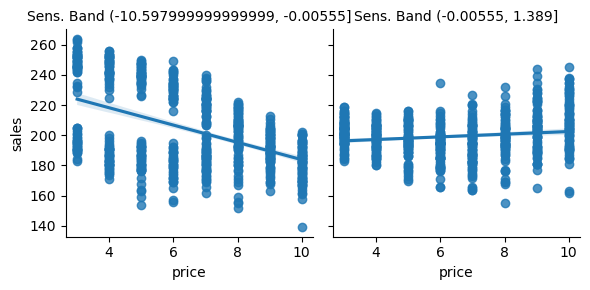

In [11]:
g = sns.FacetGrid(bands_df, col='sens_band')
g.map_dataframe(sns.regplot, x='price', y='sales')
g.set_titles(col_template='Sens. Band {col_name}');

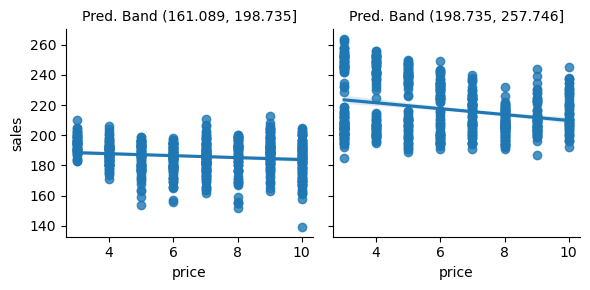

In [12]:
g = sns.FacetGrid(bands_df, col='pred_band')
g.map_dataframe(sns.regplot, x='price', y='sales')
g.set_titles(col_template='Pred. Band {col_name}');

Bir kere ilk bakışta direkt olarak bir fark görüyoruz iki yaklaşımda: Tahminsel modelde dikey eksene göre ayrılmış duruyor gözlem birimleri -- yani tahminsel model aslında yapması gerekeni yapıyor -- tahmin ediyor. Tahminsel model az dondurma satılan günlerle çok dondurma satılan günleri ayırmış, dikey eksenden anlayabiliriz bunu. Ancak bize bu lazım değil, zaten regresyon çizgisinden anlaşılıyor.

Ancak causal modelde ayrım hassasiyete göre yapılmış: Soldaki plotta fiyat arttıkça satışlar azalıyor. Ancak ikincisinde neredeyse değişmiyor (hafif pozitif eğim muhtemelen noise sadece).

## MODEL BAŞARISI ÖLÇMEYİ BİRAZ AÇALIM

In [13]:
prices = pd.read_csv('ice_cream_sales.csv') # non-random
prices_rnd = pd.read_csv('ice_cream_sales_rnd.csv') # random
print(prices_rnd.shape)
prices.head()

(5000, 5)


,temp,weekday,cost,price,sales
0,17.3,6,1.5,5.6,173
1,25.4,3,0.3,4.9,196
2,23.3,5,1.5,7.6,207
3,26.9,1,0.3,5.3,241
4,20.2,1,1.0,7.2,227


Bu sefer tamamen seçkisiz atanmış verimiz yok. Genelde böyle random data elde edince bunu model evaluation için kullanıyorlar, çok değerli olduğundan.

Biz yine iki model kuralım, karşılaştırma yapacağız çünkü.

In [14]:
m1 = smf.ols('sales ~ price*cost + price*C(weekday) + price*temp', data=prices).fit()

In [15]:
X = ['temp', 'weekday', 'cost', 'price']
y = 'sales'

np.random.seed(1)
m2 = GradientBoostingRegressor()
m2.fit(prices[X], prices[y])

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [16]:
print('Train Score:', m2.score(prices[X], prices[y]))
print('Test Score:', m2.score(prices_rnd[X], prices_rnd[y]))

Train Score: 0.9251704824568053
Test Score: 0.7711074163447709


Overfitlememek lazım normalde, ancak regularizationın yarattığı sorunlar var causality özelinde (problems with ML in causality diye aratabilirsiniz ya da ben başka zaman anlatabilirim). Çok dallanıp budaklanmamak adına devam ediyorum. Yine _numerical approximation_ yapacağız, türev biliyorsunuz zaten: 

$\displaystyle \frac{\delta y(t)}{\delta t} \approx  \frac{y(t+h) - y(t)}{h}$

In [17]:
def predict_sensitivity(model, price_df, h=0.01):
    return (model.predict(price_df.assign(price=price_df['price']+h))
            - model.predict(price_df)) / h

np.random.seed(123)
prices_rnd_pred = prices_rnd.assign(**{
    'sensitivity_m_pred': predict_sensitivity(m1, prices_rnd), ## hassasiyet modeli
    'pred_m_pred': m2.predict(prices_rnd[X]), ## tahmin modeli
    'rand_m_pred': np.random.uniform(size=prices_rnd.shape[0]), ## rastgele model
})

prices_rnd_pred.head()

,temp,weekday,cost,price,sales,sensitivity_m_pred,pred_m_pred,rand_m_pred
0,25.8,1,0.3,7,230,-13.096964,224.067406,0.696469
1,22.7,3,0.5,4,190,1.054695,189.889147,0.286139
2,33.7,7,1.0,5,237,-17.362642,237.255157,0.226851
3,23.0,4,0.5,5,193,0.564985,186.688619,0.551315
4,24.4,1,1.0,3,252,-13.717946,250.342203,0.719469


Şimdii, causality'nin temel problemi individual treatment effect'i gözlemleyemiyor olmamız. Tahminsel modeldeki gibi bir referans gerçekliğimiz yok. Dolayısıyla öyle bir karşılaştırma yapamıyoruz (accuracy, MSE vesaire gibi).

Bir şey daha, genel olarak causal inference'ta "binary" case daha kolay ve daha bilindiktir. Continuous case daha zordur. O sebeple ilk olarak binary bir örnek düşünelim. Low price vs high price, yatay eksende model skorları:

<img src='model_eval1.png'> 

Model-1 predictive model gibi duruyor çünkü satışlar ile korelasyonu mevcut. Ancak her bir grup içerisinde ATE çok değişmiyor, işimizi görmez. Model-2'de ise her bir grupta ATE farklı, bu işimizi görebilir! Sonuncusu ise beklediğimiz gibi.

Buradan neye ihtiyacımız olduğunu anladık bence: Gruplar ATE'ye göre sıralı olsun ve gruplar arasındaki fark maksimum olsun! Bu ATE'yi estimate etmek basit, tek değişkenli regresyon. Treatment'ı generic şekilde T alırsak:

$\hat{\beta_1}=\dfrac{\sum (t_i - \bar{t}) (y_i - \bar{y})}{\sum(t_i - \bar{t})^2}$

In [18]:
@curry
def sensitivity(data, y, t):
        return (np.sum((data[t] - data[t].mean())*(data[y] - data[y].mean())) /
                np.sum((data[t] - data[t].mean())**2))

In [19]:
def sensitivity_by_band(df, pred, y, t, bands=10):
    return (df
            .assign(**{f'{pred}_band':pd.qcut(df[pred], q=bands)}) # model skorlarına göre bantlar
            .groupby(f'{pred}_band') # bantlara göre group_by
            .apply(sensitivity(y=y, t=t))) # her bir bantta ATE

/var/folders/dt/nbwg86c95qz9_scgxs_48q_m0000gn/T/ipykernel_11839/4135423893.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(f'{pred}_band') # bantlara göre group_by
/var/folders/dt/nbwg86c95qz9_scgxs_48q_m0000gn/T/ipykernel_11839/4135423893.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sensitivity(y=y, t=t))) # her bir bantta ATE
/var/folders/dt/nbwg86c95qz9_scgxs_48q_m0000gn/T/ipykernel_11839/4135423893.py:4: FutureWarning: The default of observed=False is deprecated and will be changed

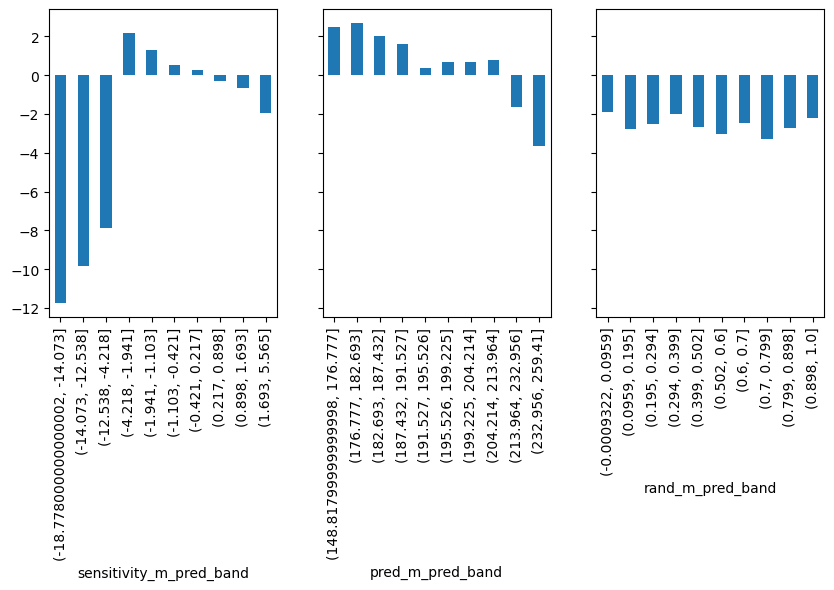

In [20]:
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(10, 4))
for m, ax in zip(['sensitivity_m_pred', 'pred_m_pred', 'rand_m_pred'], axs):
    sensitivity_by_band(prices_rnd_pred, m, 'sales', 'price').plot.bar(ax=ax)

Rastgele model direkt olarak useless -- her bir bantta ATE aynı. İlginç bir şekilde tahmin modeli fena durmuyor: Sensitivitysi az olan bantlar var (ATE'si 0'a yakın olan) ve yüksek olan bantlar var. Hassasiyet modeli bayağı acayip: Ekstrem hassasiyet olan 3 grup var, onları ve kalanını ayırabiliyor.

Peki, hangisi o zaman? Tahminsel model mi hassasiyet modeli mi?

Bunun için _cumulative sensitivity curve_'e bakacağız. Bu grupları en hassas olandan en az olana göre sıralayıp, sonrasında kumüle bir şekilde tek değişkenli regresyon runladığımızı düşünün. Yani yukarıdaki fonksiyonu iteratif bir şekilde runlayacağız.

Bunun şöyle bir avantajı var: Böyle 10'lu gruba ayırmak durumunda değiliz, belirli bir sayıda gözlem birimiyle başlayıp sonrasında tüm datada iteratif bir şekilde runlayabiliriz. Eğer model hassasiyete göre iyi sıralıyorsa k'ye kadar olanların hassasiyeti k+a'ya kadar olanlardan büyük olmalı: $\hat{y}'(t)_k > \hat{y}'(t)_{k+a}$.

Aynı zamanda sıralamada k'ya kadar olanlarla k+a'ya kadar olanlar arasındaki hassasiyet farkı da maksimum olsun istiyoruz: $\hat{y}'(t)_k - \hat{y}'(t)_{k+a}$

In [21]:
def cumulative_sensitivity_curve(dataset, prediction, y, t, min_periods=30, steps=100):
    size = dataset.shape[0]
    
    # `prediction` sütununa göre dataframei sıralıyoruz
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    
    # bir dizi indeks üretiyoruz yukarıda bahsettiğimiz k'ya denk gelecek
    n_rows = list(range(min_periods, size, size // steps)) + [size]
    
    # Kümüle hassasiyet. İlk hesaplama için minimum sample size alıyor, 
    # sonrasında hep iteratif (min_sample_size + steps*1, steps*2)...
    return np.array([sensitivity(ordered_df.head(rows), y, t) for rows in n_rows])

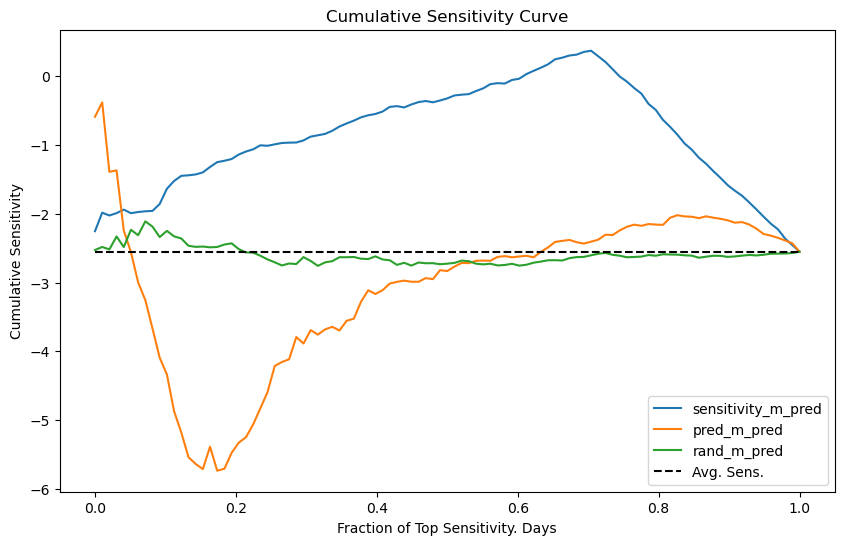

In [22]:
plt.figure(figsize=(10,6))

for m in ['sensitivity_m_pred', 'pred_m_pred', 'rand_m_pred']:
    cumu_sens = cumulative_sensitivity_curve(prices_rnd_pred, m, 'sales', 'price', min_periods=100, steps=100)
    x = np.array(range(len(cumu_sens)))
    plt.plot(x/x.max(), cumu_sens, label=m)

plt.hlines(sensitivity(prices_rnd_pred, 'sales', 'price'), 0, 1, linestyles='--', color='black', label='Avg. Sens.')
plt.xlabel('Fraction of Top Sensitivity. Days')
plt.ylabel('Cumulative Sensitivity')
plt.title('Cumulative Sensitivity Curve')
plt.legend()

İdeal bir eğride yukarıdan başlayıp oldukça yavaş bir şekilde veri setindeki ATE'ye convergelemesini bekleriz (en son tüm veriyle runlamış oluyoruz ya regresyonu). Bakınca hiçbiri öyle gözükmüyor:

Rastgele olan direkt veri seti ortalamasında fluctuate ediyor. Yani herhangi bir şekilde ATE'den farklılık gösteren gruplar bulamıyor.
Tahmin modeli biraz garip. Hem ters sıralıyor (ATE'nin altında başlıyor) hem de çok erken ATE'ye converge ediyor.
Causal model da çok iyi değil ama vaati var: %75 civarlarında ATE 0, yani treatleyebileceğimiz bir %75 var.

Cumulative gain curve bunun bir ilerisi: Mesela verinin %40'ında hassasiyet -0.5 ise 0.4 x -0.5'ten -0.2 elde ediyoruz. 

In [23]:
def cumulative_gain(dataset, prediction, y, t, min_periods=30, steps=100):
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(min_periods, size, size // steps)) + [size]
    
    ## normalizer
    return np.array([sensitivity(ordered_df.head(rows), y, t) * (rows/size) for rows in n_rows])

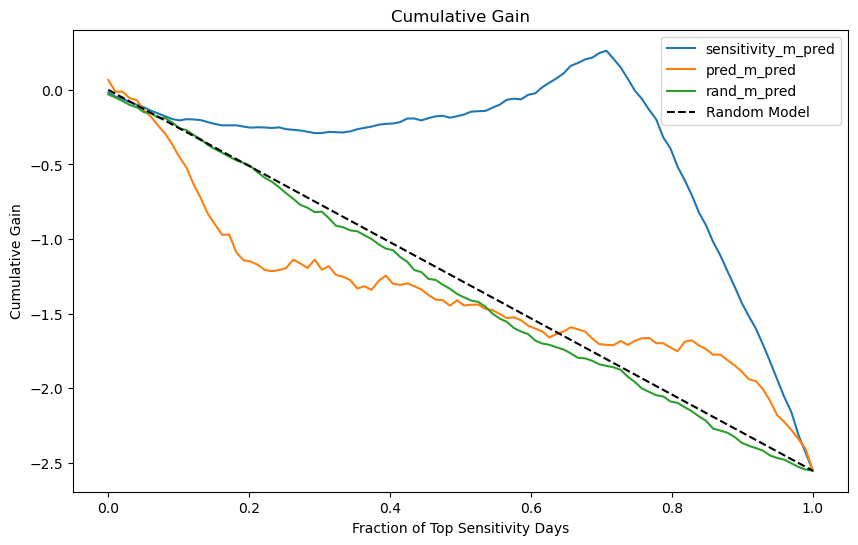

In [24]:
plt.figure(figsize=(10,6))

for m in ['sensitivity_m_pred', 'pred_m_pred', 'rand_m_pred']:
    cumu_gain = cumulative_gain(prices_rnd_pred, m, "sales", "price", min_periods=50, steps=100)
    x = np.array(range(len(cumu_gain)))
    plt.plot(x/x.max(), cumu_gain, label=m)
    
plt.plot([0, 1], [0, sensitivity(prices_rnd_pred, 'sales', 'price')], linestyle='--', label='Random Model', color='black')

plt.xlabel('Fraction of Top Sensitivity Days')
plt.ylabel('Cumulative Gain')
plt.title('Cumulative Gain')
plt.legend()

Rastgele modelden ne kadar fazla saparsak o kadar iyi: Dolayısıyla hassasiyet modeli bu plotta farkını bariz gösteriyor.

Pekala, burada duracağım çünkü buradan sonrası karmaşıklaşıyor iyice: Target transformations, metalearners, double ML. Bir de bunları anlatmak için propensity ($e(X)$), Frisch-Waugh-Lovell teoremi vesaire anlatmak gerekiyor. Dallanıp budaklanıyor anlayacağınız ki daha değişken seçimi olayına girmedik, onun için de DAG anlatmak gerekiyor. Bunları buraya yazıyorum ki kendiniz bakmak isterseniz bakın diye. Eğer istek olursa ben de anlatabilirim.

Genel bir giriş yaptığımızı ve nedensel bakış açısına bir aşinalık yarattığımızı düşünüyorum. Üzerine sohbet ederiz.